findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


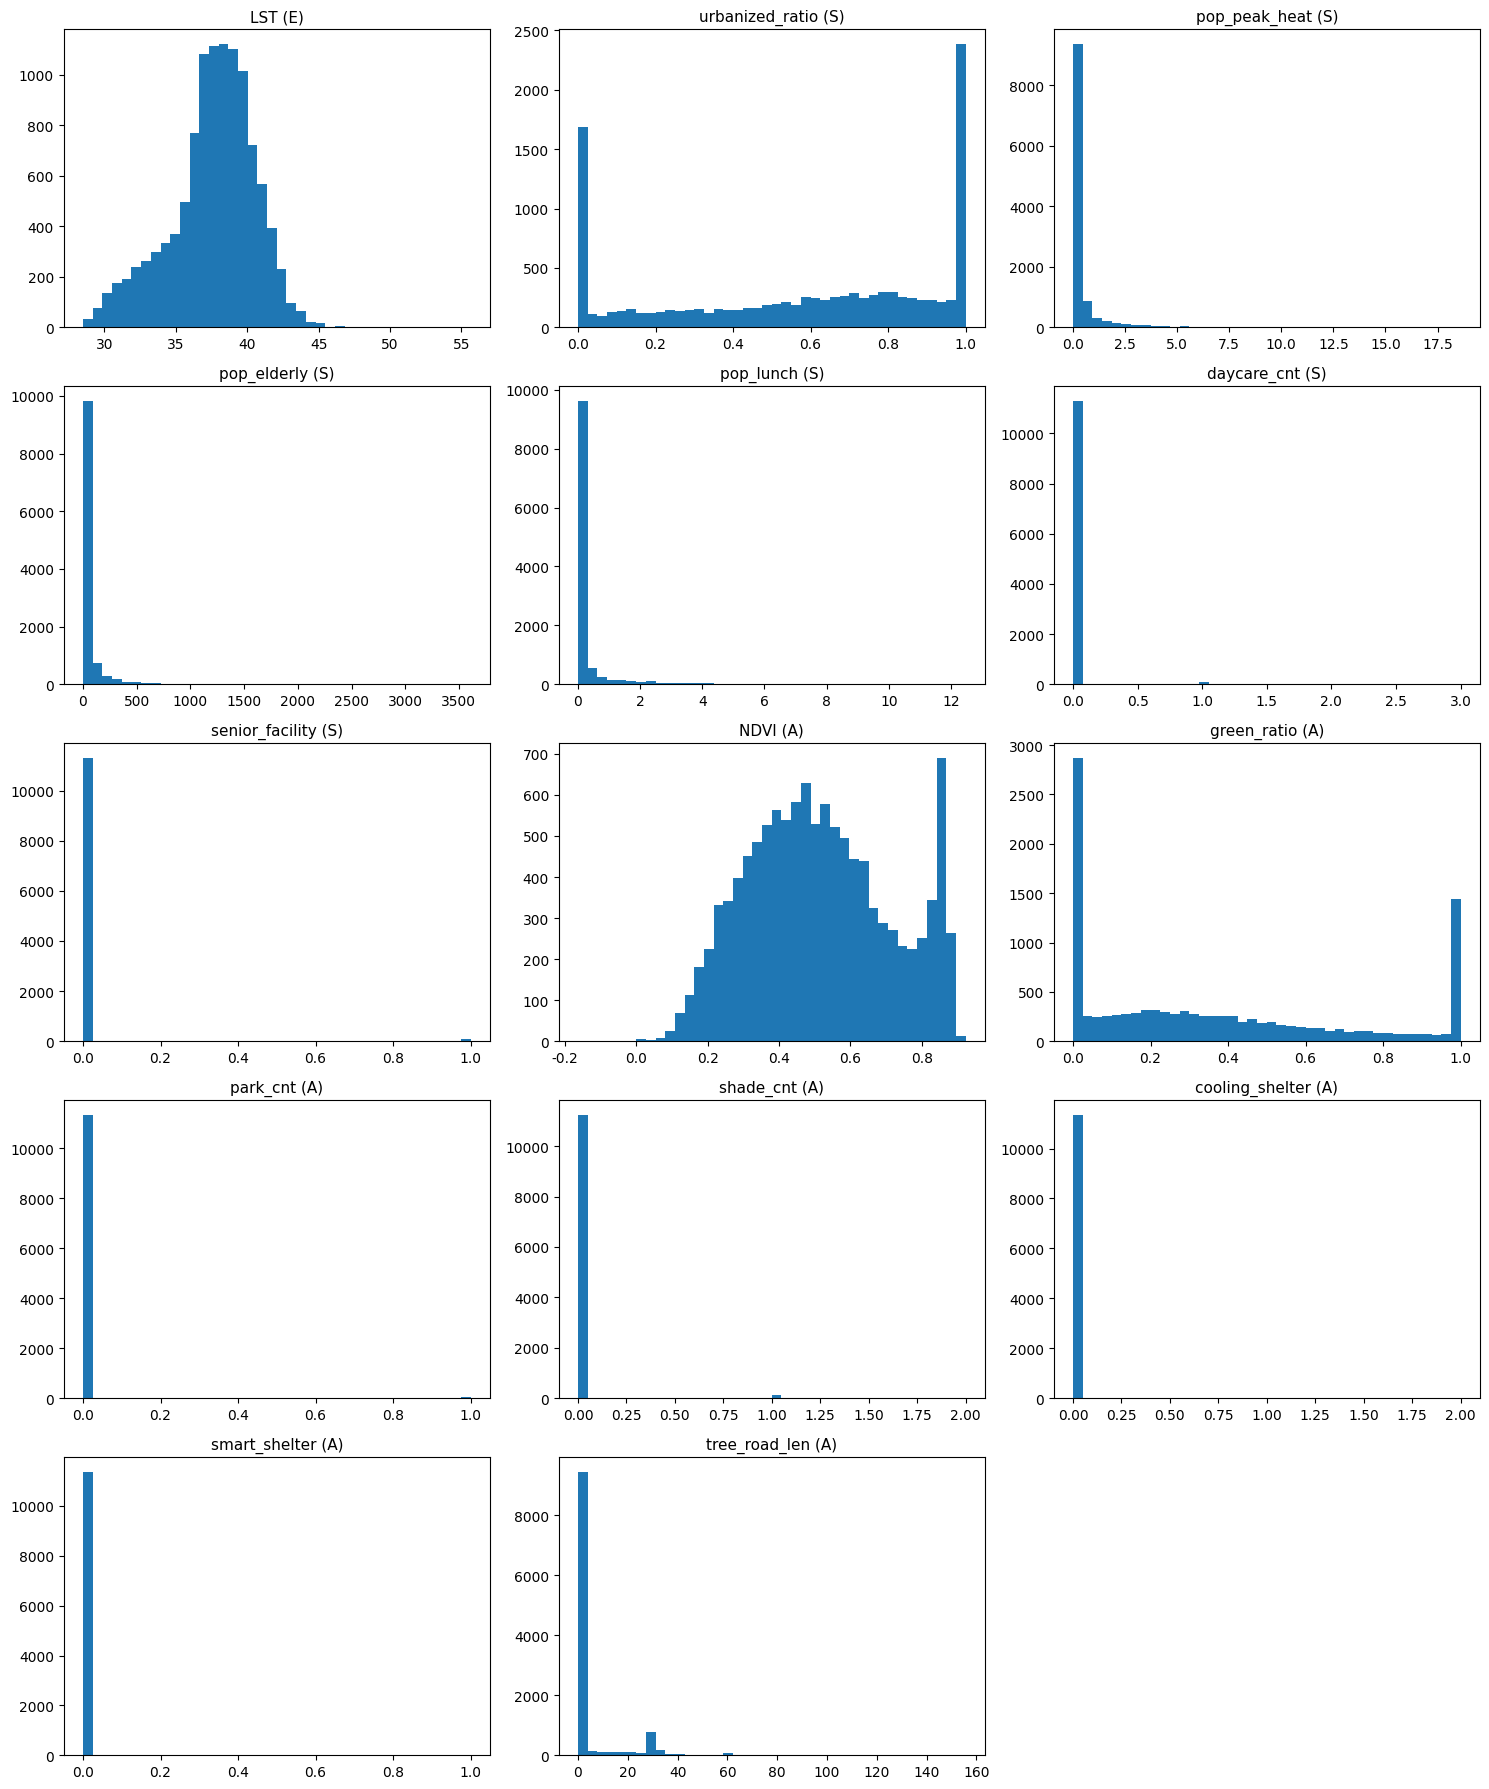

In [2]:
## 10-1: 전체 지표 히스토그램 (영문 라벨, 노트북에서 바로 보기)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('grid_HSI_selected_indicators.csv')

# 한글 컬럼명 -> 영문 라벨 매핑 (제목 깨짐 방지용)
col_label_map = {
    'LST_C_mean_5scene': 'LST (E)',
    'LC1_100_시가화건조지역_ratio': 'urbanized_ratio (S)',
    'pop_peak_h': 'pop_peak_heat (S)',
    'pop_elderl': 'pop_elderly (S)',
    'pop_lunch_': 'pop_lunch (S)',
    'daycare_cnt': 'daycare_cnt (S)',
    'senior_facility_total': 'senior_facility (S)',
    'NDVI_mean_5scene': 'NDVI (A)',
    'GREEN_ratio_LC': 'green_ratio (A)',
    'park_cnt': 'park_cnt (A)',
    'shade_cnt': 'shade_cnt (A)',
    'cooling_shelter_cnt': 'cooling_shelter (A)',
    'smart_shelter_cnt': 'smart_shelter (A)',
    'tree_road_len': 'tree_road_len (A)',
}

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, (col, label) in enumerate(col_label_map.items()):
    axes[i].hist(df[col].dropna(), bins=40)
    axes[i].set_title(label, fontsize=11)

for j in range(len(col_label_map), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [3]:
## 10-2: 대응인프라 4종 통합 (park·shade·cooling_shelter·smart_shelter)

df = pd.read_csv('grid_HSI_selected_indicators.csv')

# 4개 시설 카운트 합산 -> 폭염 대응 인프라 총합
df['adaptive_facility_total'] = (
    df['park_cnt'] + df['shade_cnt'] +
    df['cooling_shelter_cnt'] + df['smart_shelter_cnt']
)

print("adaptive_facility_total 생성 완료")
print(df['adaptive_facility_total'].describe())
print()
print("nonzero 격자 수:", (df['adaptive_facility_total'] > 0).sum(), "/", len(df))

# 원본 4개 컬럼은 제외하고 통합 컬럼으로 교체
df_final = df.drop(columns=['park_cnt', 'shade_cnt', 'cooling_shelter_cnt', 'smart_shelter_cnt'])

print("\n최종 컬럼 수:", len(df_final.columns))
print(df_final.columns.tolist())

adaptive_facility_total 생성 완료
count    11388.000000
mean         0.019845
std          0.144424
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: adaptive_facility_total, dtype: float64

nonzero 격자 수: 218 / 11388

최종 컬럼 수: 19
['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat', 'pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'tree_road_len', 'NDVI_mean_5scene', 'LST_C_mean_5scene', 'LC1_100_시가화건조지역_ratio', 'GREEN_ratio_LC', 'senior_facility_total', 'adaptive_facility_total']


In [4]:
## 10-3: 최종 표준화 (E/S/A 축)

import pandas as pd
import numpy as np

df = pd.read_csv('grid_HSI_selected_indicators.csv')

df['adaptive_facility_total'] = (
    df['park_cnt'] + df['shade_cnt'] +
    df['cooling_shelter_cnt'] + df['smart_shelter_cnt']
)

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

def log_minmax(s):
    return minmax(np.log1p(s))

# ── E축 ──
e_std = pd.DataFrame(index=df.index)
e_std['LST_C_mean_5scene'] = minmax(df['LST_C_mean_5scene'])

# ── S축 ──
s_std = pd.DataFrame(index=df.index)
s_std['LC1_100_시가화건조지역_ratio'] = minmax(df['LC1_100_시가화건조지역_ratio'])
for col in ['pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'senior_facility_total']:
    s_std[col] = log_minmax(df[col])

# ── A축 ──
a_std = pd.DataFrame(index=df.index)
a_std['NDVI_mean_5scene'] = minmax(df['NDVI_mean_5scene'])
a_std['GREEN_ratio_LC'] = minmax(df['GREEN_ratio_LC'])
for col in ['adaptive_facility_total', 'tree_road_len']:
    a_std[col] = log_minmax(df[col])

# A축은 분모라 0 방지 -> epsilon 하한
EPS = 0.01
a_std = a_std.clip(lower=EPS)

print("=== E축 표준화 결과 ===")
print(e_std.describe())
print("\n=== S축 표준화 결과 ===")
print(s_std.describe())
print("\n=== A축 표준화 결과 ===")
print(a_std.describe())

print("\n결측치 확인 (E/S/A):", e_std.isna().sum().sum(), s_std.isna().sum().sum(), a_std.isna().sum().sum())

=== E축 표준화 결과 ===
       LST_C_mean_5scene
count       10955.000000
mean            0.335521
std             0.110673
min             0.000000
25%             0.280501
50%             0.347954
75%             0.408773
max             1.000000

=== S축 표준화 결과 ===
       LC1_100_시가화건조지역_ratio    pop_peak_h    pop_elderl    pop_lunch_  \
count           11388.000000  11388.000000  11388.000000  11388.000000   
mean                0.577869      0.083996      0.347572      0.066404   
std                 0.360192      0.129198      0.180903      0.134285   
min                 0.000000      0.000000      0.000000      0.000000   
25%                 0.255175      0.014139      0.220828      0.005068   
50%                 0.651300      0.036818      0.335294      0.015128   
75%                 0.924225      0.088506      0.461922      0.048073   
max                 1.000000      1.000000      1.000000      1.000000   

        daycare_cnt  senior_facility_total  
count  11388.000000       

In [5]:
## 10-4: E축 결측치 처리 (평균 대체)

print("처리 전 결측:", e_std['LST_C_mean_5scene'].isna().sum())

e_mean = e_std['LST_C_mean_5scene'].mean()
e_std['LST_C_mean_5scene'] = e_std['LST_C_mean_5scene'].fillna(e_mean)

print("처리 후 결측:", e_std['LST_C_mean_5scene'].isna().sum())
print("대체에 사용된 평균값:", round(e_mean, 4))
print()
print(e_std.describe())

처리 전 결측: 433
처리 후 결측: 0
대체에 사용된 평균값: 0.3355

       LST_C_mean_5scene
count       11388.000000
mean            0.335521
std             0.108548
min             0.000000
25%             0.283819
50%             0.342794
75%             0.406561
max             1.000000


In [6]:
## 10-5: 표준화 완료본 저장

import pandas as pd

# grid_id, geometry 등 메타정보 다시 붙이기
meta_cols_final = df[['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat']]

df_standardized = pd.concat([meta_cols_final, e_std, s_std, a_std], axis=1)

df_standardized.to_csv('grid_HSI_standardized_stage10.csv', index=False, encoding='utf-8-sig')

print("저장 완료: grid_HSI_standardized_stage10.csv")
print(f"행 수: {len(df_standardized):,}개, 컬럼 수: {len(df_standardized.columns)}개")
print()
print("E축 컬럼:", e_std.columns.tolist())
print("S축 컬럼:", s_std.columns.tolist())
print("A축 컬럼:", a_std.columns.tolist())

저장 완료: grid_HSI_standardized_stage10.csv
행 수: 11,388개, 컬럼 수: 19개

E축 컬럼: ['LST_C_mean_5scene']
S축 컬럼: ['LC1_100_시가화건조지역_ratio', 'pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'senior_facility_total']
A축 컬럼: ['NDVI_mean_5scene', 'GREEN_ratio_LC', 'adaptive_facility_total', 'tree_road_len']
